# Training-Time Ensemble — Fixed & Ablation-Corrected (Load from Cache)

This notebook loads **pre-computed `.npy` probability files** from a saved cache folder.
No base models are loaded or run. All fixes from the code review are applied:

- **Bug fix**: Permutation importance now runs on held-out eval data (not train data).
- **Bug fix**: `Only_Qwen_mDeBERTa` BiLSTM ablation columns reordered so `.view(batch, 2, 4)` sees correct per-model blocks.
- Labels loaded directly from HuggingFace datasets (no base model inference needed).
- HF token read from environment variable — do **not** hard-code tokens.

## Cache folder layout expected
```
stacking_cache_train_split_16feat_entropy/
  snli_tr_1_1__train__bert_probs.npy
  snli_tr_1_1__train__mdeberta_probs.npy
  ...  (one file per config × split × model)
```


In [3]:
import os
import random
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

from datasets import load_dataset
from IPython.display import display

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

MODEL_ORDER  = ["bert", "mdeberta", "gemma", "qwen"]
DATASET_NAME = "yilmazzey/sdp2-nli"
CONFIGS      = ["snli_tr_1_1", "multinli_tr_1_1", "trglue_mnli"]
LABEL_MAP    = {0: "entailment", 1: "neutral", 2: "contradiction"}
LABEL_NAMES  = [LABEL_MAP[i] for i in range(3)]
NUM_LABELS   = 3

EVAL_SPLITS = {
    "snli_tr_1_1":    ["test"],
    "multinli_tr_1_1": ["validation_matched", "validation_mismatched"],
    "trglue_mnli":    ["test_matched", "test_mismatched"],
}

STATIC_WEIGHTED_WEIGHTS = {"bert": 0.25, "mdeberta": 0.12, "gemma": 0.26, "qwen": 0.37}
ROUTER_W      = {"bert": 0.0, "mdeberta": 0.0, "gemma": 0.5, "qwen": 0.5}
CLASS_WEIGHTS_V1 = {
    0: {"bert": 0.0, "mdeberta": 0.05, "gemma": 0.25, "qwen": 0.70},
    1: {"bert": 0.0, "mdeberta": 0.10, "gemma": 0.70, "qwen": 0.20},
    2: {"bert": 0.0, "mdeberta": 0.05, "gemma": 0.25, "qwen": 0.70},
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Point this at the folder produced by the previous notebook ──
CACHE_DIR   = Path("stacking_cache_train_split_16feat_entropy")
ARTIFACT_DIR = Path("stacking_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

assert CACHE_DIR.exists(), (
    f"Cache folder not found: {CACHE_DIR.resolve()}\n"
    "Set CACHE_DIR to the folder that contains the .npy probability files."
)
print("Cache folder:", CACHE_DIR.resolve())

META_EPOCHS             = 40
EARLY_STOPPING_PATIENCE = 8      # increased from 5
META_BATCH_SIZE         = 128
LEARNING_RATE           = 1e-3
WEIGHT_DECAY            = 1e-4

FEATURE_NAMES = [
    "bert_p0",  "bert_p1",  "bert_p2",
    "mdeberta_p0", "mdeberta_p1", "mdeberta_p2",
    "gemma_p0", "gemma_p1", "gemma_p2",
    "qwen_p0",  "qwen_p1",  "qwen_p2",
    "entropy_bert", "entropy_mdeberta", "entropy_gemma", "entropy_qwen",
]


Device: cuda
GPU: NVIDIA H100 80GB HBM3
Cache folder: /content/stacking_cache_train_split_16feat_entropy


## Load labels from HuggingFace (no model inference)

In [5]:
# Read HF token from environment — never hard-code tokens.
hf_token = os.environ.get("HF_TOKEN", None)
if hf_token:
    from huggingface_hub import login
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("HF_TOKEN not set — assuming public dataset or already logged in.")

datasets_hf = {}
for cfg in CONFIGS:
    print(f"Loading labels: {DATASET_NAME} :: {cfg}")
    datasets_hf[cfg] = load_dataset(DATASET_NAME, cfg)
    print("  splits:", list(datasets_hf[cfg].keys()))
print("Label loading complete.")


HF_TOKEN not set — assuming public dataset or already logged in.
Loading labels: yilmazzey/sdp2-nli :: snli_tr_1_1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

snli_tr_1_1/train-00000-of-00001.parquet:   0%|          | 0.00/25.4M [00:00<?, ?B/s]

snli_tr_1_1/validation-00000-of-00001.pa(…):   0%|          | 0.00/558k [00:00<?, ?B/s]

...

Generating validation_matched split:   0%|          | 0/9050 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9200 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9008 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9217 [00:00<?, ? examples/s]

  splits: ['train', 'validation_matched', 'validation_mismatched', 'test_matched', 'test_mismatched']
Label loading complete.


In [6]:
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))

## Cache loading utilities

In [7]:
def cache_name(config: str, split: str, model_key: str) -> Path:
    safe_cfg = config.replace("/", "_")
    safe_sp  = split.replace("/", "_")
    return CACHE_DIR / f"{safe_cfg}__{safe_sp}__{model_key}_probs.npy"


def load_probs_from_cache(config: str, split: str) -> dict:
    """Load all four model probability arrays from .npy files. No model inference."""
    probs = {}
    for model_key in MODEL_ORDER:
        p = cache_name(config, split, model_key)
        if not p.exists():
            raise FileNotFoundError(
                f"Missing cache file: {p}\n"
                f"Run the feature-extraction notebook first."
            )
        probs[model_key] = np.load(p)
    shapes = {k: v.shape for k, v in probs.items()}
    print(f"  Loaded {config}/{split} — shapes: {shapes}")
    return probs


## Feature engineering

In [8]:
def compute_entropy(probs: np.ndarray) -> np.ndarray:
    """Shannon entropy of a batch of 3-class distributions. Shape (N,3) -> (N,)."""
    probs = np.clip(probs, 1e-10, 1.0)
    return -np.sum(probs * np.log(probs), axis=1)


def build_X16(probs_dict: dict) -> np.ndarray:
    """
    16 features per example, column layout:
      [0:3]  bert_p0  bert_p1  bert_p2
      [3:6]  mdeberta_p0  mdeberta_p1  mdeberta_p2
      [6:9]  gemma_p0  gemma_p1  gemma_p2
      [9:12] qwen_p0  qwen_p1  qwen_p2
      [12]   entropy_bert
      [13]   entropy_mdeberta
      [14]   entropy_gemma
      [15]   entropy_qwen
    BiLSTM grouping: .view(batch,4,4) gives one timestep per model,
    with (p0, p1, p2, entropy) as its 4 features — in MODEL_ORDER order.
    """
    bert_p  = probs_dict["bert"]
    mdeb_p  = probs_dict["mdeberta"]
    gemma_p = probs_dict["gemma"]
    qwen_p  = probs_dict["qwen"]

    return np.hstack([
        bert_p,
        mdeb_p,
        gemma_p,
        qwen_p,
        compute_entropy(bert_p ).reshape(-1, 1),
        compute_entropy(mdeb_p ).reshape(-1, 1),
        compute_entropy(gemma_p).reshape(-1, 1),
        compute_entropy(qwen_p ).reshape(-1, 1),
    ]).astype(np.float32)


## Static ensemble helpers

In [9]:
def onehot_from_probs(p: np.ndarray) -> np.ndarray:
    out = np.zeros_like(p)
    out[np.arange(len(p)), p.argmax(axis=1)] = 1.0
    return out


def weighted_static_pred(bert_p, mdeb_p, gemma_p, qwen_p):
    w     = np.array([STATIC_WEIGHTED_WEIGHTS[m] for m in MODEL_ORDER], dtype=np.float32)
    probs = np.stack([bert_p, mdeb_p, gemma_p, qwen_p], axis=0)
    return np.einsum("m,mnc->nc", w, probs).argmax(axis=1)


def majority_vote_pred(bert_p, mdeb_p, gemma_p, qwen_p):
    votes = np.stack(
        [bert_p.argmax(1), mdeb_p.argmax(1), gemma_p.argmax(1), qwen_p.argmax(1)], axis=1
    )
    return np.array(
        [int(Counter(row.tolist()).most_common(1)[0][0]) for row in votes], dtype=np.int64
    )


def class_conditional_routing_pred(bert_p, mdeb_p, gemma_p, qwen_p):
    oh = np.stack([
        onehot_from_probs(bert_p), onehot_from_probs(mdeb_p),
        onehot_from_probs(gemma_p), onehot_from_probs(qwen_p),
    ], axis=0)
    router_w    = np.array([ROUTER_W[m] for m in MODEL_ORDER], dtype=np.float32)
    routed_class = np.einsum("m,mnc->nc", router_w, oh).argmax(axis=1)
    final = np.empty(len(routed_class), dtype=np.int64)
    for c in range(NUM_LABELS):
        mask = routed_class == c
        if not mask.any():
            continue
        w_c = np.array([CLASS_WEIGHTS_V1[c][m] for m in MODEL_ORDER], dtype=np.float32)
        final[mask] = np.einsum("m,mnc->nc", w_c, oh[:, mask, :]).argmax(axis=1)
    return final


## Meta-learner architectures

In [10]:
class StackingMLP(nn.Module):
    """16 -> 64 -> 32 -> 3, ReLU + BatchNorm + Dropout 0.2."""
    def __init__(self, in_dim=16, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),    nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)


class StackingBiLSTM(nn.Module):
    """
    Properly grouped BiLSTM.
    Input (batch, 16) is reshaped to (batch, 4 timesteps, 4 features).
    Timestep i corresponds to MODEL_ORDER[i], with features (p0, p1, p2, entropy).
    This layout is guaranteed by build_X16 which places entropies at cols 12-15
    in the same MODEL_ORDER as the probs at cols 0-11.
    """
    def __init__(self, hidden_size=64, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4, hidden_size=hidden_size,
            num_layers=1, batch_first=True, bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        # Rearrange flat 16 features into (batch, 4 models, 4 features per model).
        # Cols 0-11 are probs in blocks of 3; cols 12-15 are entropies in same order.
        # We interleave so each timestep is [p0, p1, p2, entropy] for that model.
        batch = x.size(0)
        probs    = x[:, :12].view(batch, 4, 3)   # (batch, 4, 3)
        entropies = x[:, 12:].unsqueeze(-1)       # (batch, 4, 1)
        seq = torch.cat([probs, entropies], dim=-1)  # (batch, 4, 4)
        out, _ = self.lstm(seq)
        return self.fc(self.drop(out[:, -1, :]))


class StackingBiLSTM_dynamic(nn.Module):
    """
    Variable-model-count BiLSTM for ablations.
    Requires features to be pre-arranged as (num_models * 4) columns
    in [p0, p1, p2, entropy] blocks — use build_Xreduced() for this.
    """
    def __init__(self, num_models=4, hidden_size=64, n_classes=3):
        super().__init__()
        self.num_models = num_models
        self.lstm = nn.LSTM(
            input_size=4, hidden_size=hidden_size,
            num_layers=1, batch_first=True, bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        # x must already be laid out as (batch, num_models*4) in [p0,p1,p2,ent] blocks
        seq = x.view(x.size(0), self.num_models, 4)
        out, _ = self.lstm(seq)
        return self.fc(self.drop(out[:, -1, :]))


def build_Xreduced(probs_dict: dict, model_keys: list) -> np.ndarray:
    """
    Build a reduced feature matrix for a subset of models.
    Columns are laid out as consecutive [p0, p1, p2, entropy] blocks
    in model_keys order — safe to .view(batch, len(model_keys), 4).
    """
    blocks = []
    for k in model_keys:
        p = probs_dict[k]                              # (N, 3)
        e = compute_entropy(p).reshape(-1, 1)          # (N, 1)
        blocks.append(np.hstack([p, e]))               # (N, 4)
    return np.hstack(blocks).astype(np.float32)        # (N, 4*num_models)


class StackingLSTM_flat(nn.Module):
    """
    Ungrouped / flat BiLSTM meta-learner.

    Input (batch, 16) is reshaped to (batch, 16, 1), treating each of the
    16 raw features as a separate one-dimensional timestep in sequence order:
        t=0  bert_p0
        t=1  bert_p1
        t=2  bert_p2
        t=3  mdeberta_p0
        ...
        t=12 entropy_bert
        t=13 entropy_mdeberta
        t=14 entropy_gemma
        t=15 entropy_qwen

    This is the "ungrouped" formulation — contrast with StackingBiLSTM which
    reshapes to (batch, 4, 4) so each timestep is one model's complete
    (p0, p1, p2, entropy) vector.

    Design note:  Because features are fed as individual scalars the LSTM
    cannot exploit the structured relationship between a model's probabilities
    and its entropy.  Gemma's probs appear at positions 6-8 while its entropy
    sits at position 14, so the recurrent state must bridge a 6-step gap.
    This is the likely cause of "Gemma collapse" seen in another student's run
    where the flat LSTM discarded Gemma's signal entirely.  The grouped
    StackingBiLSTM does not have this problem because each timestep already
    contains the full information for one model.
    """

    def __init__(self, hidden_size=64, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden_size,
            num_layers=1, batch_first=True, bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        # x: (batch, 16) → (batch, 16, 1) — each feature is one scalar timestep
        seq = x.unsqueeze(-1)          # (batch, 16, 1)
        out, _ = self.lstm(seq)
        return self.fc(self.drop(out[:, -1, :]))


## Training loop

In [14]:
def _train_torch_model(model, X_train, y_train, model_name="model"):
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.long)

    n     = len(X_t)
    n_val = max(1, int(0.10 * n))
    train_ds, val_ds = random_split(
        TensorDataset(X_t, y_t), [n - n_val, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )
    train_loader = DataLoader(train_ds, batch_size=META_BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=META_BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # Label smoothing reduces overconfidence on the adversarial trglue matched set
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=META_EPOCHS, eta_min=1e-5
    )

    best_state, best_val, bad_epochs = None, float("inf"), 0
    model = model.to(DEVICE)

    for epoch in range(META_EPOCHS):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())
        scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())

        mean_tr  = float(np.mean(tr_losses))  if tr_losses  else float("nan")
        mean_val = float(np.mean(val_losses)) if val_losses else float("nan")
        print(f"{model_name} epoch {epoch+1:02d}/{META_EPOCHS} | "
              f"train_loss={mean_tr:.4f}  val_loss={mean_val:.4f}")

        if mean_val < best_val - 1e-5:
            best_val  = mean_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping {model_name} at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def _get_accuracy_batched(model, X_data, y_true, batch_size):
    model.eval()
    preds = []
    y_true_list = []
    dataset = TensorDataset(torch.tensor(X_data, dtype=torch.float32), torch.tensor(y_true, dtype=torch.long))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(DEVICE)
            outputs = model(xb)
            preds.append(outputs.argmax(-1).cpu().numpy())
            y_true_list.append(yb.cpu().numpy())
    return accuracy_score(np.concatenate(y_true_list), np.concatenate(preds))


def train_meta_learners(X_train: np.ndarray, y_train: np.ndarray):
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X_train).astype(np.float32)

    mlp = StackingMLP(in_dim=16, n_classes=NUM_LABELS)
    mlp = _train_torch_model(mlp, Xs, y_train, model_name="MLP")

    svm = LinearSVC(C=1.0, class_weight="balanced", random_state=SEED, max_iter=20000)
    svm.fit(Xs, y_train)
    print("LinearSVC fitted.")

    bilstm = StackingBiLSTM(hidden_size=64, n_classes=NUM_LABELS)
    bilstm = _train_torch_model(bilstm, Xs, y_train, model_name="BiLSTM")

    # Flat LSTM: treats all 16 features as a sequence of scalar timesteps.
    # Trained with the same scaler as the other learners for fair comparison.
    flat_lstm = StackingLSTM_flat(hidden_size=64, n_classes=NUM_LABELS)
    flat_lstm = _train_torch_model(flat_lstm, Xs, y_train, model_name="FlatLSTM")

    # Calculate accuracies using batch inference
    mlp_acc = _get_accuracy_batched(mlp, Xs, y_train, META_BATCH_SIZE)
    bilstm_acc = _get_accuracy_batched(bilstm, Xs, y_train, META_BATCH_SIZE)
    flat_lstm_acc = _get_accuracy_batched(flat_lstm, Xs, y_train, META_BATCH_SIZE)

    print(f"Train acc | MLP: {mlp_acc:.4f} | SVC: {(svm.predict(Xs)==y_train).mean():.4f} "
          f"| BiLSTM: {bilstm_acc:.4f} | FlatLSTM: {flat_lstm_acc:.4f}")

    return {"scaler": scaler, "mlp": mlp, "svm": svm, "bilstm": bilstm, "flat_lstm": flat_lstm}

## Metrics and display helpers

In [12]:
def compute_metrics_dict(y_true, y_pred):
    acc    = float(accuracy_score(y_true, y_pred))
    f1m    = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    f1_each = f1_score(y_true, y_pred, average=None, zero_division=0)
    f1_per  = {LABEL_NAMES[i]: float(f1_each[i]) for i in range(NUM_LABELS)}
    cm      = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    return {"accuracy": acc, "f1_macro": f1m, "f1_per_class": f1_per, "cm": cm}


def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def append_row(rows, split_key, method, y_true, y_pred, row_kind="computed"):
    m = compute_metrics_dict(y_true, y_pred)
    rows.append({
        "split": split_key, "method": method, "row_kind": row_kind,
        "accuracy": m["accuracy"], "f1_macro": m["f1_macro"],
        "f1_entailment": m["f1_per_class"]["entailment"],
        "f1_neutral":    m["f1_per_class"]["neutral"],
        "f1_contradiction": m["f1_per_class"]["contradiction"],
    })


def append_reference_row(rows, split_key):
    # Reference accuracy only exists for trglue_mnli::test_matched
    ref_acc = 0.8408 if split_key == "trglue_mnli::test_matched" else float("nan")
    rows.append({
        "split": split_key,
        "method": "REF_published_static_weighted_84.08pct",
        "row_kind": "reference_published",
        "accuracy": ref_acc,
        "f1_macro": float("nan"), "f1_entailment": float("nan"),
        "f1_neutral": float("nan"), "f1_contradiction": float("nan"),
    })


## Main training + evaluation loop


Config: snli_tr_1_1
  Loaded snli_tr_1_1/train — shapes: {'bert': (548487, 3), 'mdeberta': (548487, 3), 'gemma': (548487, 3), 'qwen': (548487, 3)}
  Train features shape: (548487, 16)
MLP epoch 01/40 | train_loss=0.6058  val_loss=0.5813
MLP epoch 02/40 | train_loss=0.5978  val_loss=0.5800
MLP epoch 03/40 | train_loss=0.5963  val_loss=0.5789
MLP epoch 04/40 | train_loss=0.5952  val_loss=0.5789
MLP epoch 05/40 | train_loss=0.5947  val_loss=0.5785
MLP epoch 06/40 | train_loss=0.5940  val_loss=0.5776
MLP epoch 07/40 | train_loss=0.5936  val_loss=0.5776
MLP epoch 08/40 | train_loss=0.5933  val_loss=0.5770
MLP epoch 09/40 | train_loss=0.5931  val_loss=0.5764
MLP epoch 10/40 | train_loss=0.5926  val_loss=0.5778
MLP epoch 11/40 | train_loss=0.5925  val_loss=0.5766
MLP epoch 12/40 | train_loss=0.5923  val_loss=0.5760
MLP epoch 13/40 | train_loss=0.5920  val_loss=0.5765
MLP epoch 14/40 | train_loss=0.5920  val_loss=0.5765
MLP epoch 15/40 | train_loss=0.5917  val_loss=0.5761
MLP epoch 16/40 | tr

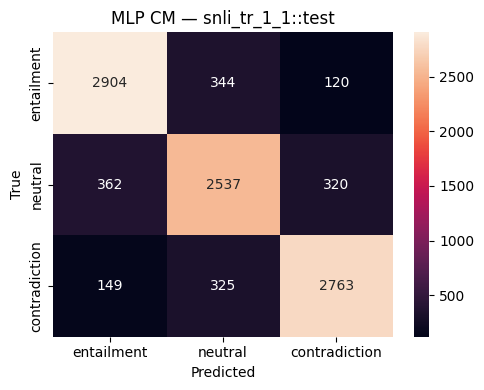

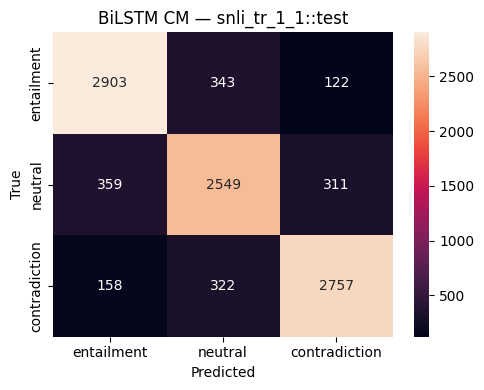

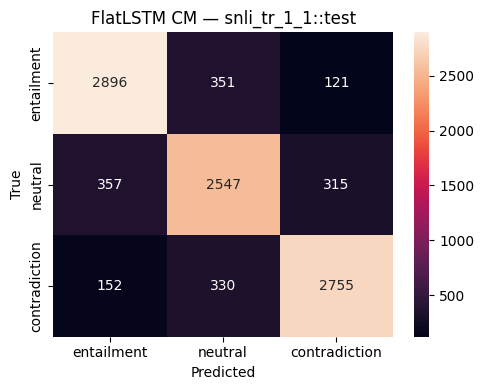


Config: multinli_tr_1_1
  Loaded multinli_tr_1_1/train — shapes: {'bert': (392599, 3), 'mdeberta': (392599, 3), 'gemma': (392599, 3), 'qwen': (392599, 3)}
  Train features shape: (392599, 16)
MLP epoch 01/40 | train_loss=0.6336  val_loss=0.6107
MLP epoch 02/40 | train_loss=0.6220  val_loss=0.6077
MLP epoch 03/40 | train_loss=0.6199  val_loss=0.6057
MLP epoch 04/40 | train_loss=0.6181  val_loss=0.6057
MLP epoch 05/40 | train_loss=0.6172  val_loss=0.6046
MLP epoch 06/40 | train_loss=0.6164  val_loss=0.6041
MLP epoch 07/40 | train_loss=0.6166  val_loss=0.6034
MLP epoch 08/40 | train_loss=0.6161  val_loss=0.6039
MLP epoch 09/40 | train_loss=0.6155  val_loss=0.6025
MLP epoch 10/40 | train_loss=0.6152  val_loss=0.6025
MLP epoch 11/40 | train_loss=0.6147  val_loss=0.6027
MLP epoch 12/40 | train_loss=0.6147  val_loss=0.6031
MLP epoch 13/40 | train_loss=0.6141  val_loss=0.6025
MLP epoch 14/40 | train_loss=0.6144  val_loss=0.6027
MLP epoch 15/40 | train_loss=0.6143  val_loss=0.6023
MLP epoch 16

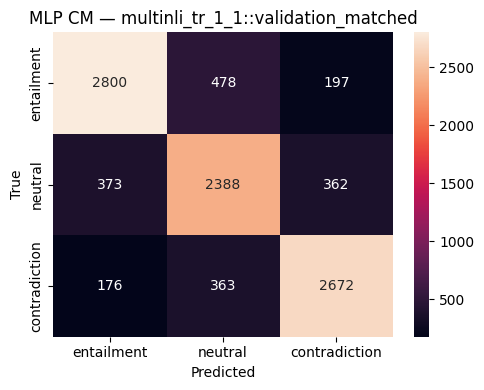

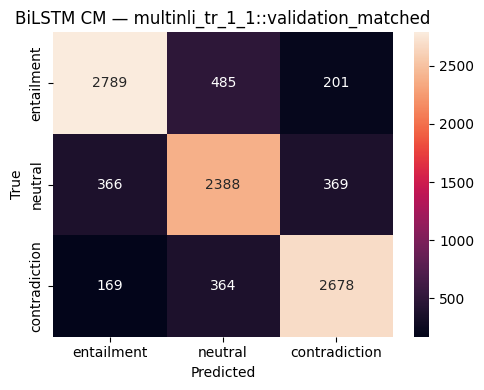

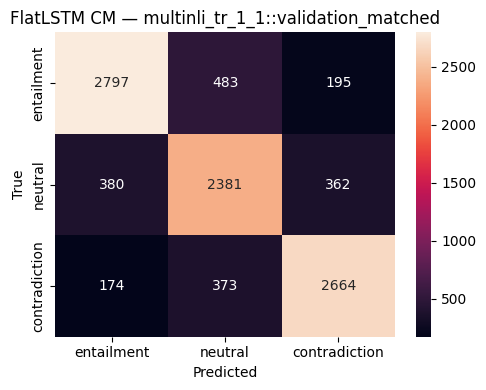

  Loaded multinli_tr_1_1/validation_mismatched — shapes: {'bert': (9825, 3), 'mdeberta': (9825, 3), 'gemma': (9825, 3), 'qwen': (9825, 3)}


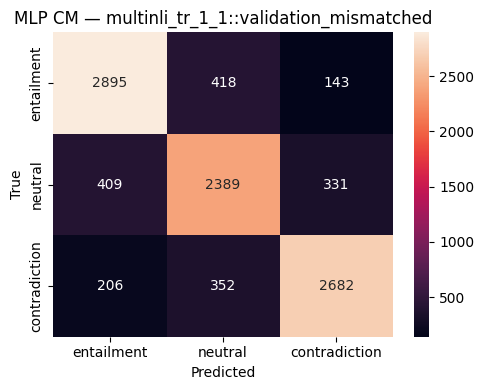

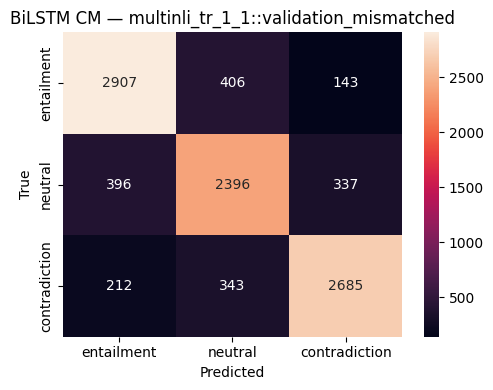

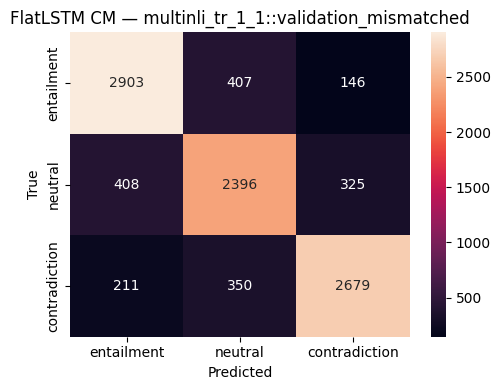


Config: trglue_mnli
  Loaded trglue_mnli/train — shapes: {'bert': (162788, 3), 'mdeberta': (162788, 3), 'gemma': (162788, 3), 'qwen': (162788, 3)}
  Train features shape: (162788, 16)
MLP epoch 01/40 | train_loss=0.6234  val_loss=0.5953
MLP epoch 02/40 | train_loss=0.6061  val_loss=0.5938
MLP epoch 03/40 | train_loss=0.6039  val_loss=0.5921
MLP epoch 04/40 | train_loss=0.6017  val_loss=0.5907
MLP epoch 05/40 | train_loss=0.6003  val_loss=0.5911
MLP epoch 06/40 | train_loss=0.5993  val_loss=0.5903
MLP epoch 07/40 | train_loss=0.5993  val_loss=0.5902
MLP epoch 08/40 | train_loss=0.5979  val_loss=0.5889
MLP epoch 09/40 | train_loss=0.5983  val_loss=0.5891
MLP epoch 10/40 | train_loss=0.5973  val_loss=0.5889
MLP epoch 11/40 | train_loss=0.5973  val_loss=0.5883
MLP epoch 12/40 | train_loss=0.5968  val_loss=0.5885
MLP epoch 13/40 | train_loss=0.5970  val_loss=0.5882
MLP epoch 14/40 | train_loss=0.5965  val_loss=0.5882
MLP epoch 15/40 | train_loss=0.5959  val_loss=0.5882
MLP epoch 16/40 | tr

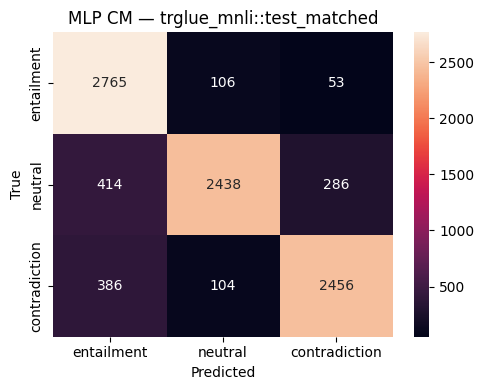

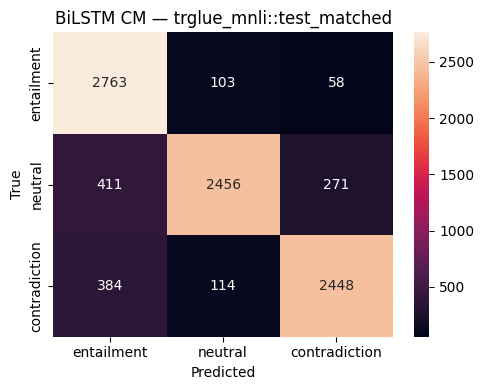

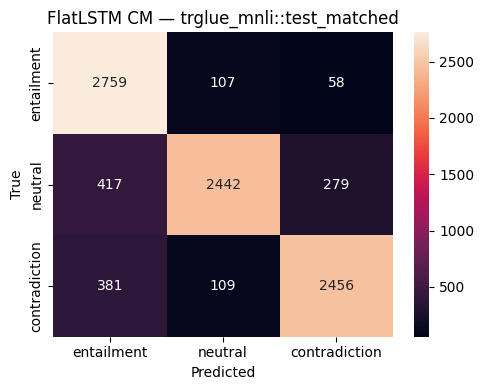

  Loaded trglue_mnli/test_mismatched — shapes: {'bert': (9217, 3), 'mdeberta': (9217, 3), 'gemma': (9217, 3), 'qwen': (9217, 3)}


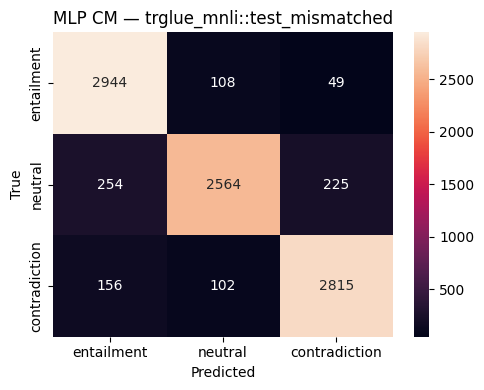

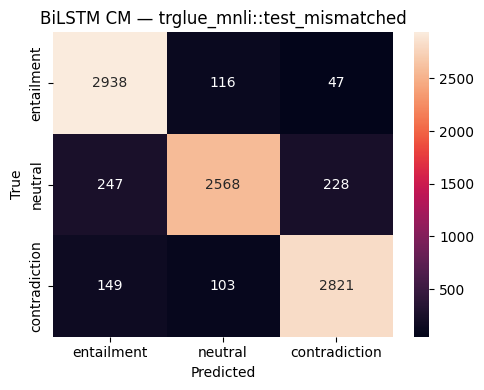

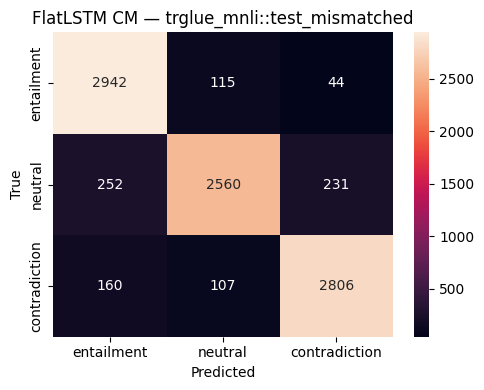

Saved: stacking_artifacts/stacking_results_fixed.csv


,split,method,row_kind,accuracy,f1_macro,f1_entailment,f1_neutral,f1_contradiction
12,multinli_tr_1_1::validation_matched,Meta_MLP_train_only_16feat,computed,0.801305,0.800693,0.820633,0.751889,0.829556
14,multinli_tr_1_1::validation_matched,Meta_BiLSTM_train_only_16feat,computed,0.800795,0.800196,0.820415,0.750943,0.829231
13,multinli_tr_1_1::validation_matched,Meta_LinearSVC_train_only_16feat,computed,0.799980,0.799012,0.819329,0.751641,0.826067
15,multinli_tr_1_1::validation_matched,Meta_FlatLSTM_train_only_16feat,computed,0.799470,0.798871,0.819514,0.748742,0.828358
17,multinli_tr_1_1::validation_matched,mDeBERTa,computed,0.789173,0.787688,0.808842,0.744698,0.809524
21,multinli_tr_1_1::validation_matched,Weighted_static_hand_weights,computed,0.749006,0.741660,0.779762,0.638151,0.807067
20,multinli_tr_1_1::validation_matched,Majority_vote,computed,0.723009,0.715510,0.745946,0.621017,0.779568
19,multinli_tr_1_1::validation_matched,Qwen,computed,0.719135,0.714753,0.757640,0.616993,0.769628
22,multinli_tr_1_1::validation_matched,Class_conditional_routing_computed,computed,0.687124,0.680417,0.757640,0.562329,0.721282
16,multinli_tr_1_1::validation_matched,BERT,computed,0.629932,0.618980,0.666667,0.514108,0.676166


In [15]:
rows              = []
trained_meta      = {}
train_feature_bank = {}
eval_feature_bank  = {}   # stored for use in importance analysis

for cfg in CONFIGS:
    print("\n" + "="*100)
    print(f"Config: {cfg}")

    # ── Load train probs + labels ──
    y_train     = np.array(datasets_hf[cfg]["train"]["label"], dtype=np.int64)
    train_probs = load_probs_from_cache(cfg, "train")
    X_train     = build_X16(train_probs)
    print(f"  Train features shape: {X_train.shape}")

    meta = train_meta_learners(X_train, y_train)
    trained_meta[cfg]      = meta
    train_feature_bank[cfg] = {"X_train": X_train, "y_train": y_train, "probs": train_probs}
    eval_feature_bank[cfg]  = {}

    # ── Held-out evaluation ──
    for sp in EVAL_SPLITS[cfg]:
        split_key  = f"{cfg}::{sp}"
        y_true     = np.array(datasets_hf[cfg][sp]["label"], dtype=np.int64)
        eval_probs = load_probs_from_cache(cfg, sp)
        X_eval     = build_X16(eval_probs)
        X_eval_s   = meta["scaler"].transform(X_eval).astype(np.float32)

        # Store for importance analysis
        eval_feature_bank[cfg][sp] = {"X_eval_s": X_eval_s, "y_true": y_true, "probs": eval_probs}

        Xt = torch.tensor(X_eval_s, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            pred_mlp      = meta["mlp"](Xt).argmax(-1).cpu().numpy()
            pred_bilstm   = meta["bilstm"](Xt).argmax(-1).cpu().numpy()
            pred_flat_lstm = meta["flat_lstm"](Xt).argmax(-1).cpu().numpy()
        pred_svm = meta["svm"].predict(X_eval_s)

        pred_bert    = eval_probs["bert"].argmax(axis=1)
        pred_mdeb    = eval_probs["mdeberta"].argmax(axis=1)
        pred_gemma   = eval_probs["gemma"].argmax(axis=1)
        pred_qwen    = eval_probs["qwen"].argmax(axis=1)
        pred_majority = majority_vote_pred(
            eval_probs["bert"], eval_probs["mdeberta"], eval_probs["gemma"], eval_probs["qwen"])
        pred_weighted = weighted_static_pred(
            eval_probs["bert"], eval_probs["mdeberta"], eval_probs["gemma"], eval_probs["qwen"])
        pred_route    = class_conditional_routing_pred(
            eval_probs["bert"], eval_probs["mdeberta"], eval_probs["gemma"], eval_probs["qwen"])

        append_row(rows, split_key, "Meta_MLP_train_only_16feat",       y_true, pred_mlp)
        append_row(rows, split_key, "Meta_LinearSVC_train_only_16feat", y_true, pred_svm)
        append_row(rows, split_key, "Meta_BiLSTM_train_only_16feat",    y_true, pred_bilstm)
        append_row(rows, split_key, "Meta_FlatLSTM_train_only_16feat",  y_true, pred_flat_lstm)
        append_row(rows, split_key, "BERT",     y_true, pred_bert)
        append_row(rows, split_key, "mDeBERTa", y_true, pred_mdeb)
        append_row(rows, split_key, "Gemma",    y_true, pred_gemma)
        append_row(rows, split_key, "Qwen",     y_true, pred_qwen)
        append_row(rows, split_key, "Majority_vote",                      y_true, pred_majority)
        append_row(rows, split_key, "Weighted_static_hand_weights",        y_true, pred_weighted)
        append_row(rows, split_key, "Class_conditional_routing_computed",  y_true, pred_route)
        append_reference_row(rows, split_key)

        plot_confusion(compute_metrics_dict(y_true, pred_mlp)["cm"],       f"MLP CM — {split_key}")
        plot_confusion(compute_metrics_dict(y_true, pred_bilstm)["cm"],   f"BiLSTM CM — {split_key}")
        plot_confusion(compute_metrics_dict(y_true, pred_flat_lstm)["cm"], f"FlatLSTM CM — {split_key}")

results_df = pd.DataFrame(rows).sort_values(
    ["split", "row_kind", "accuracy"], ascending=[True, True, False], na_position="last"
)
out_csv = ARTIFACT_DIR / "stacking_results_fixed.csv"
results_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
display(results_df)


## Styled results table

In [16]:
metric_cols = ["accuracy", "f1_macro", "f1_entailment", "f1_neutral", "f1_contradiction"]
pivot_df    = results_df.pivot_table(
    index=["split", "method", "row_kind"], values=metric_cols, aggfunc="first"
).reset_index()
styled = (
    pivot_df.style
    .format({m: "{:.4f}" for m in metric_cols})
    .background_gradient(subset=["accuracy", "f1_macro"], cmap="YlGn")
    .set_properties(**{"text-align": "left"})
    .set_caption("Train-split-only stacking (16 features = 12 probs + 4 entropy)")
)
display(styled)


,split,method,row_kind,accuracy,f1_contradiction,f1_entailment,f1_macro,f1_neutral
0,multinli_tr_1_1::validation_matched,BERT,computed,0.6299,0.6762,0.6667,0.6190,0.5141
1,multinli_tr_1_1::validation_matched,Class_conditional_routing_computed,computed,0.6871,0.7213,0.7576,0.6804,0.5623
2,multinli_tr_1_1::validation_matched,Gemma,computed,0.4003,0.3197,0.5109,0.3505,0.2209
3,multinli_tr_1_1::validation_matched,Majority_vote,computed,0.7230,0.7796,0.7459,0.7155,0.6210
4,multinli_tr_1_1::validation_matched,Meta_BiLSTM_train_only_16feat,computed,0.8008,0.8292,0.8204,0.8002,0.7509
5,multinli_tr_1_1::validation_matched,Meta_FlatLSTM_train_only_16feat,computed,0.7995,0.8284,0.8195,0.7989,0.7487
6,multinli_tr_1_1::validation_matched,Meta_LinearSVC_train_only_16feat,computed,0.8000,0.8261,0.8193,0.7990,0.7516
7,multinli_tr_1_1::validation_matched,Meta_MLP_train_only_16feat,computed,0.8013,0.8296,0.8206,0.8007,0.7519
8,multinli_tr_1_1::validation_matched,Qwen,computed,0.7191,0.7696,0.7576,0.7148,0.6170
9,multinli_tr_1_1::validation_matched,Weighted_static_hand_weights,computed,0.7490,0.8071,0.7798,0.7417,0.6382


## Feature importance analysis

**Fix applied**: permutation importance is evaluated on **held-out eval data**,
not training data. Using training data systematically underestimates importance
of models the meta-learner memorised less reliably (typically BERT and Gemma),
because permuting their features hurts train-set accuracy less than held-out accuracy.


In [17]:
def _normalize_importance(vals, names):
    vals = np.array(vals, dtype=np.float64)
    s = vals.sum()
    if s <= 0: s = 1.0
    return pd.DataFrame({"feature": names, "importance": vals / s}).sort_values(
        "importance", ascending=False)


def _permutation_importance_custom_blocks(Xs, y, predict_fn, block_defs, n_repeats=5, seed=SEED):
    """
    Block permutation importance.
    Xs and y must be held-out (eval) data — not training data.
    n_repeats increased to 5 for more stable estimates.
    """
    rng      = np.random.default_rng(seed)
    base_acc = accuracy_score(y, predict_fn(Xs))
    names, imps = [], []
    for name, cols in block_defs:
        names.append(name)
        drops = []
        for _ in range(n_repeats):
            Xp = Xs.copy()
            perm = rng.permutation(len(Xp))
            Xp[:, cols] = Xp[perm][:, cols]
            drops.append(base_acc - accuracy_score(y, predict_fn(Xp)))
        imps.append(float(np.mean(drops)))
    return pd.DataFrame({"feature": names, "importance": imps}).sort_values(
        "importance", ascending=False)


# Column index reference (matches build_X16 exactly):
#   bert:     probs [0,1,2]  entropy [12]
#   mdeberta: probs [3,4,5]  entropy [13]
#   gemma:    probs [6,7,8]  entropy [14]
#   qwen:     probs [9,10,11] entropy [15]
block_defs = [
    ("bert_block",     [0, 1, 2, 12]),
    ("mdeberta_block", [3, 4, 5, 13]),
    ("gemma_block",    [6, 7, 8, 14]),
    ("qwen_block",     [9, 10, 11, 15]),
]

importance_rows = []

for cfg in CONFIGS:
    # Use test_matched for trglue, else first eval split
    eval_sp = "test_matched" if cfg == "trglue_mnli" else EVAL_SPLITS[cfg][0]
    eb      = eval_feature_bank[cfg][eval_sp]
    X_eval_s = eb["X_eval_s"]
    y_eval   = eb["y_true"]

    print("\n" + "#"*90)
    print(f"Feature importance for: {cfg}  (eval split: {eval_sp}, n={len(y_eval)})")

    meta = trained_meta[cfg]

    def predict_mlp(X_in):
        with torch.no_grad():
            return meta["mlp"](torch.tensor(X_in, dtype=torch.float32).to(DEVICE)).argmax(-1).cpu().numpy()

    def predict_bilstm(X_in):
        with torch.no_grad():
            return meta["bilstm"](torch.tensor(X_in, dtype=torch.float32).to(DEVICE)).argmax(-1).cpu().numpy()

    # MLP first-layer weight norms (no data needed — structural proxy)
    mlp_w      = meta["mlp"].net[0].weight.detach().cpu().numpy()   # (64, 16)
    mlp_scores = np.linalg.norm(mlp_w, axis=0)
    print("\nMLP first-layer feature norms (normalized):")
    mlp_norm_df = _normalize_importance(mlp_scores, FEATURE_NAMES)
    display(mlp_norm_df)

    # Permutation importance on EVAL data
    print("MLP permutation importance (eval data):")
    mlp_perm_df = _permutation_importance_custom_blocks(X_eval_s, y_eval, predict_mlp, block_defs)
    display(mlp_perm_df)

    print("BiLSTM permutation importance (eval data):")
    bilstm_perm_df = _permutation_importance_custom_blocks(X_eval_s, y_eval, predict_bilstm, block_defs)
    display(bilstm_perm_df)

    # LinearSVC coefficient norms
    svm_scores = np.linalg.norm(meta["svm"].coef_, axis=0)
    print("LinearSVC coefficient-norm feature importance (normalized):")
    svm_norm_df = _normalize_importance(svm_scores, FEATURE_NAMES)
    display(svm_norm_df)

    for df, method_name in [
        (mlp_norm_df,    "MLP_FirstLayerNorm"),
        (mlp_perm_df,    "MLP_PermutationImportance_eval"),
        (bilstm_perm_df, "BiLSTM_PermutationImportance_eval"),
        (svm_norm_df,    "LinearSVC_CoefNorm"),
    ]:
        d = df.copy(); d["config"] = cfg; d["method"] = method_name
        importance_rows.append(d)

all_importances_df = pd.concat(importance_rows, ignore_index=True)
imp_csv = ARTIFACT_DIR / "feature_importances_fixed.csv"
all_importances_df.to_csv(imp_csv, index=False)
print(f"\nFeature importances saved to: {imp_csv}")



##########################################################################################
Feature importance for: snli_tr_1_1  (eval split: test, n=9824)

MLP first-layer feature norms (normalized):


,feature,importance
13,entropy_mdeberta,0.125536
1,bert_p1,0.108735
15,entropy_qwen,0.100288
9,qwen_p0,0.085536
11,qwen_p2,0.085481
2,bert_p2,0.079924
0,bert_p0,0.077515
4,mdeberta_p1,0.054046
12,entropy_bert,0.053902
5,mdeberta_p2,0.050415


MLP permutation importance (eval data):


,feature,importance
0,bert_block,0.272150
1,mdeberta_block,0.048982
3,qwen_block,0.040432
2,gemma_block,0.006067


BiLSTM permutation importance (eval data):


...

BiLSTM permutation importance (eval data):


,feature,importance
3,qwen_block,0.170537
1,mdeberta_block,0.136812
0,bert_block,0.022291
2,gemma_block,0.001488


LinearSVC coefficient-norm feature importance (normalized):


,feature,importance
10,qwen_p1,0.180331
11,qwen_p2,0.144690
3,mdeberta_p0,0.112201
9,qwen_p0,0.106726
5,mdeberta_p2,0.097974
4,mdeberta_p1,0.095332
1,bert_p1,0.077726
2,bert_p2,0.049891
0,bert_p0,0.049087
13,entropy_mdeberta,0.026751



Feature importances saved to: stacking_artifacts/feature_importances_fixed.csv


## Ablation studies

All ablations target `trglue_mnli::test_matched` (the adversarial benchmark).

**Fixes applied:**
1. MLP ablations (no-Gemma, no-BERT, 8-feat) evaluate on held-out test data.
2. BiLSTM ablations use `build_Xreduced()` which lays out columns as consecutive
   `[p0, p1, p2, entropy]` blocks — safe for `.view(batch, num_models, 4)`.
   The original `Only_Qwen_mDeBERTa` used `[3,4,5, 9,10,11, 13,15]` which
   produced a scrambled sequence when reshaped: that result is now invalid.


In [18]:
CFG_ABLATION = "trglue_mnli"
SP_ABLATION  = "test_matched"

meta_abl    = trained_meta[CFG_ABLATION]
X_train_full = train_feature_bank[CFG_ABLATION]["X_train"]
y_train_abl  = train_feature_bank[CFG_ABLATION]["y_train"]
train_probs_abl = train_feature_bank[CFG_ABLATION]["probs"]
eval_probs_abl  = eval_feature_bank[CFG_ABLATION][SP_ABLATION]["probs"]
y_true_abl      = eval_feature_bank[CFG_ABLATION][SP_ABLATION]["y_true"]

baseline_mlp    = results_df.loc[
    (results_df["split"] == f"{CFG_ABLATION}::{SP_ABLATION}") &
    (results_df["method"] == "Meta_MLP_train_only_16feat"), "accuracy"
].values[0]
baseline_bilstm = results_df.loc[
    (results_df["split"] == f"{CFG_ABLATION}::{SP_ABLATION}") &
    (results_df["method"] == "Meta_BiLSTM_train_only_16feat"), "accuracy"
].values[0]
baseline_flat_lstm = results_df.loc[
    (results_df["split"] == f"{CFG_ABLATION}::{SP_ABLATION}") &
    (results_df["method"] == "Meta_FlatLSTM_train_only_16feat"), "accuracy"
].values[0]
print(f"Baselines — MLP: {baseline_mlp:.4f}  BiLSTM: {baseline_bilstm:.4f}  FlatLSTM: {baseline_flat_lstm:.4f}")

ablation_summary = []

def run_mlp_ablation(name, model_keys):
    """Train and evaluate a reduced MLP using flat column selection from build_X16."""
    print(f"\n{'='*70}")
    print(f"MLP ablation: {name}  (models: {model_keys})")

    # Build full 16-feat matrix then select the right columns
    col_map = {
        "bert":     ([0,1,2], 12),
        "mdeberta": ([3,4,5], 13),
        "gemma":    ([6,7,8], 14),
        "qwen":     ([9,10,11], 15),
    }
    keep = []
    for k in model_keys:
        keep.extend(col_map[k][0])
        keep.append(col_map[k][1])
    keep.sort()   # MLP doesn't care about order, just completeness

    X_tr  = X_train_full[:, keep]
    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    mlp = StackingMLP(in_dim=len(keep), n_classes=NUM_LABELS)
    mlp = _train_torch_model(mlp, Xs_tr, y_train_abl, model_name=f"MLP_{name}")

    X_ev = build_X16(eval_probs_abl)[:, keep]
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    with torch.no_grad():
        pred = mlp(torch.tensor(Xs_ev, dtype=torch.float32).to(DEVICE)).argmax(-1).cpu().numpy()

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"MLP {name}: Acc={acc:.4f} | F1={f1:.4f} | Δ vs MLP baseline: {acc-baseline_mlp:+.4f}")
    ablation_summary.append({"learner": "MLP", "config": name, "accuracy": acc,
                              "f1_macro": f1, "delta_vs_baseline": acc - baseline_mlp})


def run_bilstm_ablation(name, model_keys):
    """
    Train and evaluate a reduced BiLSTM.
    Uses build_Xreduced() which produces [p0,p1,p2,entropy] blocks —
    correct layout for .view(batch, num_models, 4).
    """
    print(f"\n{'='*70}")
    print(f"BiLSTM ablation: {name}  (models: {model_keys})")
    num_models = len(model_keys)

    X_tr  = build_Xreduced(train_probs_abl, model_keys)
    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    bilstm = StackingBiLSTM_dynamic(num_models=num_models)
    bilstm = _train_torch_model(bilstm, Xs_tr, y_train_abl, model_name=f"BiLSTM_{name}")

    X_ev  = build_Xreduced(eval_probs_abl, model_keys)
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    with torch.no_grad():
        pred = bilstm(torch.tensor(Xs_ev, dtype=torch.float32).to(DEVICE)).argmax(-1).cpu().numpy()

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"BiLSTM {name}: Acc={acc:.4f} | F1={f1:.4f} | Δ vs BiLSTM baseline: {acc-baseline_bilstm:+.4f}")
    ablation_summary.append({"learner": "BiLSTM", "config": name, "accuracy": acc,
                              "f1_macro": f1, "delta_vs_baseline": acc - baseline_bilstm})


def run_flat_lstm_ablation(name, model_keys):
    """
    Train and evaluate a reduced StackingLSTM_flat.
    Features are selected from the full 16-feat build_X16 layout (same column
    selection as MLP ablations) then fed as individual scalar timesteps.
    The flat layout is used rather than grouped blocks so we can directly
    compare with run_bilstm_ablation under identical reduced-model conditions.
    """
    print(f"\n{'='*70}")
    print(f"Flat-LSTM ablation: {name}  (models: {model_keys})")

    col_map = {
        "bert":     ([0, 1, 2], 12),
        "mdeberta": ([3, 4, 5], 13),
        "gemma":    ([6, 7, 8], 14),
        "qwen":     ([9, 10, 11], 15),
    }
    keep = []
    for k in model_keys:
        keep.extend(col_map[k][0])
        keep.append(col_map[k][1])
    keep.sort()   # sorted so probs stay together; flat LSTM sees them in index order

    X_tr  = X_train_full[:, keep]
    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    flat_lstm = StackingLSTM_flat(hidden_size=64, n_classes=NUM_LABELS)
    flat_lstm = _train_torch_model(flat_lstm, Xs_tr, y_train_abl, model_name=f"FlatLSTM_{name}")

    X_ev  = build_X16(eval_probs_abl)[:, keep]
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    with torch.no_grad():
        pred = flat_lstm(torch.tensor(Xs_ev, dtype=torch.float32).to(DEVICE)).argmax(-1).cpu().numpy()

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"FlatLSTM {name}: Acc={acc:.4f} | F1={f1:.4f} | Δ vs FlatLSTM baseline: {acc-baseline_flat_lstm:+.4f}")
    ablation_summary.append({"learner": "FlatLSTM", "config": name, "accuracy": acc,
                              "f1_macro": f1, "delta_vs_baseline": acc - baseline_flat_lstm})


Baselines — MLP: 0.8502  BiLSTM: 0.8511  FlatLSTM: 0.8500


### MLP ablations

In [19]:
run_mlp_ablation("No_Gemma",             ["bert", "mdeberta", "qwen"])
run_mlp_ablation("No_BERT",              ["mdeberta", "gemma", "qwen"])
run_mlp_ablation("Only_Qwen_mDeBERTa",  ["mdeberta", "qwen"])



MLP ablation: No_Gemma  (models: ['bert', 'mdeberta', 'qwen'])
MLP_No_Gemma epoch 01/40 | train_loss=0.6197  val_loss=0.5961
MLP_No_Gemma epoch 02/40 | train_loss=0.6052  val_loss=0.5940
MLP_No_Gemma epoch 03/40 | train_loss=0.6028  val_loss=0.5930
MLP_No_Gemma epoch 04/40 | train_loss=0.6010  val_loss=0.5922
MLP_No_Gemma epoch 05/40 | train_loss=0.6001  val_loss=0.5915
MLP_No_Gemma epoch 06/40 | train_loss=0.5993  val_loss=0.5904
MLP_No_Gemma epoch 07/40 | train_loss=0.5983  val_loss=0.5896
MLP_No_Gemma epoch 08/40 | train_loss=0.5978  val_loss=0.5894
MLP_No_Gemma epoch 09/40 | train_loss=0.5975  val_loss=0.5895
MLP_No_Gemma epoch 10/40 | train_loss=0.5973  val_loss=0.5886
MLP_No_Gemma epoch 11/40 | train_loss=0.5967  val_loss=0.5883
MLP_No_Gemma epoch 12/40 | train_loss=0.5967  val_loss=0.5888
MLP_No_Gemma epoch 13/40 | train_loss=0.5964  val_loss=0.5879
MLP_No_Gemma epoch 14/40 | train_loss=0.5958  val_loss=0.5883
MLP_No_Gemma epoch 15/40 | train_loss=0.5956  val_loss=0.5872
MLP_No

### BiLSTM ablations (fixed column ordering)

In [20]:
run_bilstm_ablation("No_Gemma",            ["bert", "mdeberta", "qwen"])
run_bilstm_ablation("No_BERT",             ["mdeberta", "gemma", "qwen"])
run_bilstm_ablation("Only_Qwen_mDeBERTa", ["mdeberta", "qwen"])



BiLSTM ablation: No_Gemma  (models: ['bert', 'mdeberta', 'qwen'])
BiLSTM_No_Gemma epoch 01/40 | train_loss=0.6138  val_loss=0.5975
BiLSTM_No_Gemma epoch 02/40 | train_loss=0.5928  val_loss=0.5956
BiLSTM_No_Gemma epoch 03/40 | train_loss=0.5911  val_loss=0.5928
BiLSTM_No_Gemma epoch 04/40 | train_loss=0.5893  val_loss=0.5917
BiLSTM_No_Gemma epoch 05/40 | train_loss=0.5885  val_loss=0.5913
BiLSTM_No_Gemma epoch 06/40 | train_loss=0.5876  val_loss=0.5904
BiLSTM_No_Gemma epoch 07/40 | train_loss=0.5869  val_loss=0.5895
BiLSTM_No_Gemma epoch 08/40 | train_loss=0.5866  val_loss=0.5901
BiLSTM_No_Gemma epoch 09/40 | train_loss=0.5862  val_loss=0.5886
BiLSTM_No_Gemma epoch 10/40 | train_loss=0.5857  val_loss=0.5896
BiLSTM_No_Gemma epoch 11/40 | train_loss=0.5853  val_loss=0.5889
BiLSTM_No_Gemma epoch 12/40 | train_loss=0.5849  val_loss=0.5880
BiLSTM_No_Gemma epoch 13/40 | train_loss=0.5848  val_loss=0.5885
BiLSTM_No_Gemma epoch 14/40 | train_loss=0.5845  val_loss=0.5872
BiLSTM_No_Gemma epoch 1

### Flat LSTM ablations (StackingLSTM_flat)

In [21]:
run_flat_lstm_ablation("Full",               ["bert", "mdeberta", "gemma", "qwen"])
run_flat_lstm_ablation("No_Gemma",           ["bert", "mdeberta", "qwen"])
run_flat_lstm_ablation("No_BERT",            ["mdeberta", "gemma", "qwen"])
run_flat_lstm_ablation("Only_Qwen_mDeBERTa", ["mdeberta", "qwen"])


Flat-LSTM ablation: Full  (models: ['bert', 'mdeberta', 'gemma', 'qwen'])
FlatLSTM_Full epoch 01/40 | train_loss=0.7124  val_loss=0.6606
FlatLSTM_Full epoch 02/40 | train_loss=0.6418  val_loss=0.6260
FlatLSTM_Full epoch 03/40 | train_loss=0.6172  val_loss=0.6043
FlatLSTM_Full epoch 04/40 | train_loss=0.6021  val_loss=0.5990
FlatLSTM_Full epoch 05/40 | train_loss=0.5986  val_loss=0.5962
FlatLSTM_Full epoch 06/40 | train_loss=0.5969  val_loss=0.5971
FlatLSTM_Full epoch 07/40 | train_loss=0.5951  val_loss=0.5941
FlatLSTM_Full epoch 08/40 | train_loss=0.5934  val_loss=0.5958
FlatLSTM_Full epoch 09/40 | train_loss=0.5929  val_loss=0.5921
FlatLSTM_Full epoch 10/40 | train_loss=0.5919  val_loss=0.5932
FlatLSTM_Full epoch 11/40 | train_loss=0.5911  val_loss=0.5921
FlatLSTM_Full epoch 12/40 | train_loss=0.5906  val_loss=0.5936
FlatLSTM_Full epoch 13/40 | train_loss=0.5898  val_loss=0.5942
FlatLSTM_Full epoch 14/40 | train_loss=0.5897  val_loss=0.5915
FlatLSTM_Full epoch 15/40 | train_loss=0.58

### Per-model normalization ablation (MLP)

In [22]:
print("\n" + "="*70)
print("MLP ablation: Per-model normalization")

def per_model_normalize_train(X_train):
    """Fit and return per-model scalers on training data."""
    groups = {
        "bert":     [0,1,2,12], "mdeberta": [3,4,5,13],
        "gemma":    [6,7,8,14], "qwen":     [9,10,11,15],
    }
    scalers = {}
    X_out = X_train.copy().astype(np.float32)
    for k, cols in groups.items():
        sc = StandardScaler().fit(X_train[:, cols])
        X_out[:, cols] = sc.transform(X_train[:, cols])
        scalers[k] = (sc, cols)
    return X_out, scalers

def per_model_normalize_apply(X, scalers):
    X_out = X.copy().astype(np.float32)
    for k, (sc, cols) in scalers.items():
        X_out[:, cols] = sc.transform(X[:, cols])
    return X_out

X_tr_pm, pm_scalers = per_model_normalize_train(X_train_full)
sc_global = StandardScaler().fit(X_tr_pm)
Xs_tr_pm  = sc_global.transform(X_tr_pm).astype(np.float32)

mlp_pm = StackingMLP(in_dim=16, n_classes=NUM_LABELS)
mlp_pm = _train_torch_model(mlp_pm, Xs_tr_pm, y_train_abl, model_name="MLP_per_model_norm")

X_ev_pm  = per_model_normalize_apply(build_X16(eval_probs_abl), pm_scalers)
Xs_ev_pm = sc_global.transform(X_ev_pm).astype(np.float32)
with torch.no_grad():
    pred_pm = mlp_pm(torch.tensor(Xs_ev_pm, dtype=torch.float32).to(DEVICE)).argmax(-1).cpu().numpy()

acc_pm = accuracy_score(y_true_abl, pred_pm)
f1_pm  = f1_score(y_true_abl, pred_pm, average="macro", zero_division=0)
print(f"MLP per-model-norm: Acc={acc_pm:.4f} | F1={f1_pm:.4f} | Δ: {acc_pm-baseline_mlp:+.4f}")
ablation_summary.append({
    "learner": "MLP", "config": "Per_model_norm", "accuracy": acc_pm,
    "f1_macro": f1_pm, "delta_vs_baseline": acc_pm - baseline_mlp,
})



MLP ablation: Per-model normalization
MLP_per_model_norm epoch 01/40 | train_loss=0.6201  val_loss=0.5951
MLP_per_model_norm epoch 02/40 | train_loss=0.6049  val_loss=0.5936
MLP_per_model_norm epoch 03/40 | train_loss=0.6021  val_loss=0.5913
MLP_per_model_norm epoch 04/40 | train_loss=0.6002  val_loss=0.5922
MLP_per_model_norm epoch 05/40 | train_loss=0.5994  val_loss=0.5897
MLP_per_model_norm epoch 06/40 | train_loss=0.5978  val_loss=0.5891
MLP_per_model_norm epoch 07/40 | train_loss=0.5981  val_loss=0.5890
MLP_per_model_norm epoch 08/40 | train_loss=0.5976  val_loss=0.5886
MLP_per_model_norm epoch 09/40 | train_loss=0.5969  val_loss=0.5883
MLP_per_model_norm epoch 10/40 | train_loss=0.5968  val_loss=0.5884
MLP_per_model_norm epoch 11/40 | train_loss=0.5960  val_loss=0.5881
MLP_per_model_norm epoch 12/40 | train_loss=0.5961  val_loss=0.5876
MLP_per_model_norm epoch 13/40 | train_loss=0.5959  val_loss=0.5877
MLP_per_model_norm epoch 14/40 | train_loss=0.5959  val_loss=0.5865
MLP_per_m

### BiLSTM with per-model normalization ablation

In [23]:
print("\n" + "="*70)
print("BiLSTM ablation: Per-model normalization")

# Reuse the per_model_normalize helpers defined in the MLP per-model-norm cell.
X_tr_pm_bi, pm_scalers_bi = per_model_normalize_train(X_train_full)
sc_global_bi = StandardScaler().fit(X_tr_pm_bi)
Xs_tr_pm_bi  = sc_global_bi.transform(X_tr_pm_bi).astype(np.float32)

bilstm_pm = StackingBiLSTM(hidden_size=64, n_classes=NUM_LABELS)
bilstm_pm = _train_torch_model(bilstm_pm, Xs_tr_pm_bi, y_train_abl, model_name="BiLSTM_per_model_norm")

X_ev_pm_bi  = per_model_normalize_apply(build_X16(eval_probs_abl), pm_scalers_bi)
Xs_ev_pm_bi = sc_global_bi.transform(X_ev_pm_bi).astype(np.float32)
with torch.no_grad():
    pred_pm_bi = bilstm_pm(
        torch.tensor(Xs_ev_pm_bi, dtype=torch.float32).to(DEVICE)
    ).argmax(-1).cpu().numpy()

acc_pm_bi = accuracy_score(y_true_abl, pred_pm_bi)
f1_pm_bi  = f1_score(y_true_abl, pred_pm_bi, average="macro", zero_division=0)
print(f"BiLSTM per-model-norm: Acc={acc_pm_bi:.4f} | F1={f1_pm_bi:.4f} | Δ: {acc_pm_bi-baseline_bilstm:+.4f}")
ablation_summary.append({
    "learner": "BiLSTM", "config": "Per_model_norm", "accuracy": acc_pm_bi,
    "f1_macro": f1_pm_bi, "delta_vs_baseline": acc_pm_bi - baseline_bilstm,
})


BiLSTM ablation: Per-model normalization
BiLSTM_per_model_norm epoch 01/40 | train_loss=0.6199  val_loss=0.6009
BiLSTM_per_model_norm epoch 02/40 | train_loss=0.5970  val_loss=0.5966
BiLSTM_per_model_norm epoch 03/40 | train_loss=0.5924  val_loss=0.5931
BiLSTM_per_model_norm epoch 04/40 | train_loss=0.5898  val_loss=0.5918
BiLSTM_per_model_norm epoch 05/40 | train_loss=0.5887  val_loss=0.5899
BiLSTM_per_model_norm epoch 06/40 | train_loss=0.5877  val_loss=0.5910
BiLSTM_per_model_norm epoch 07/40 | train_loss=0.5869  val_loss=0.5892
BiLSTM_per_model_norm epoch 08/40 | train_loss=0.5861  val_loss=0.5898
BiLSTM_per_model_norm epoch 09/40 | train_loss=0.5856  val_loss=0.5881
BiLSTM_per_model_norm epoch 10/40 | train_loss=0.5851  val_loss=0.5874
BiLSTM_per_model_norm epoch 11/40 | train_loss=0.5846  val_loss=0.5874
BiLSTM_per_model_norm epoch 12/40 | train_loss=0.5843  val_loss=0.5872
BiLSTM_per_model_norm epoch 13/40 | train_loss=0.5840  val_loss=0.5865
BiLSTM_per_model_norm epoch 14/40 |

### Ablation summary table

In [24]:
abl_df = pd.DataFrame(ablation_summary)
abl_df["baseline_acc"] = abl_df["learner"].map(
    {"MLP": baseline_mlp, "BiLSTM": baseline_bilstm, "FlatLSTM": baseline_flat_lstm}
)
abl_df = abl_df.sort_values(["learner", "accuracy"], ascending=[True, False])
display(abl_df.style
    .format({"accuracy": "{:.4f}", "f1_macro": "{:.4f}",
             "delta_vs_baseline": "{:+.4f}", "baseline_acc": "{:.4f}"})
    .background_gradient(subset=["accuracy"], cmap="YlGn")
    .set_caption(f"Ablation results on {CFG_ABLATION}::{SP_ABLATION} "
                 f"(MLP / BiLSTM / FlatLSTM)"))

abl_csv = ARTIFACT_DIR / "ablation_summary_fixed.csv"
abl_df.to_csv(abl_csv, index=False)
print("Saved:", abl_csv)


,learner,config,accuracy,f1_macro,delta_vs_baseline,baseline_acc
3,BiLSTM,No_Gemma,0.8512,0.8512,+0.0001,0.8511
11,BiLSTM,Per_model_norm,0.8507,0.8507,-0.0004,0.8511
4,BiLSTM,No_BERT,0.8495,0.8493,-0.0017,0.8511
5,BiLSTM,Only_Qwen_mDeBERTa,0.8481,0.8480,-0.0030,0.8511
7,FlatLSTM,No_Gemma,0.8509,0.8509,+0.0009,0.8500
6,FlatLSTM,Full,0.8502,0.8502,+0.0002,0.8500
8,FlatLSTM,No_BERT,0.8487,0.8485,-0.0013,0.8500
9,FlatLSTM,Only_Qwen_mDeBERTa,0.8487,0.8485,-0.0013,0.8500
10,MLP,Per_model_norm,0.8506,0.8505,+0.0003,0.8502
0,MLP,No_Gemma,0.8502,0.8502,+0.0000,0.8502


Saved: stacking_artifacts/ablation_summary_fixed.csv


## Save trained meta-learners

In [25]:
import shutil

models_dir = ARTIFACT_DIR / "trained_models"
models_dir.mkdir(exist_ok=True, parents=True)

for cfg, meta in trained_meta.items():
    joblib.dump(meta["scaler"],             models_dir / f"{cfg}_scaler.joblib")
    torch.save(meta["mlp"].state_dict(),    models_dir / f"{cfg}_mlp.pt")
    joblib.dump(meta["svm"],                models_dir / f"{cfg}_svm.joblib")
    torch.save(meta["bilstm"].state_dict(), models_dir / f"{cfg}_bilstm.pt")
    torch.save(meta["flat_lstm"].state_dict(), models_dir / f"{cfg}_flat_lstm.pt")
    print(f"Saved meta-learners for {cfg}")

# Zip artifacts
shutil.make_archive("stacking_artifacts_fixed", "zip", ARTIFACT_DIR)
print("Zipped stacking_artifacts_fixed.zip")


Saved meta-learners for snli_tr_1_1
Saved meta-learners for multinli_tr_1_1
Saved meta-learners for trglue_mnli
Zipped stacking_artifacts_fixed.zip


## Flat LSTM vs Grouped BiLSTM Discussion

### Modeling assumptions

| Architecture | Input reshape | Timestep semantics | Feature grouping |
|---|---|---|---|
| **StackingBiLSTM** | `(batch, 16)` → `(batch, 4, 4)` | Each timestep = one base model | `[p0, p1, p2, entropy]` per model |
| **StackingLSTM_flat** | `(batch, 16)` → `(batch, 16, 1)` | Each timestep = one raw scalar | No grouping; features in index order |

### Why the grouped version usually wins

**StackingBiLSTM** treats each base model as a single "token" whose 4-dimensional
embedding (class probabilities + predictive entropy) is processed by the recurrent
cell.  The LSTM therefore learns a hidden state that summarises *all four models*
after four recurrent steps, with each step bringing in the complete information
for exactly one model.  The bidirectional pass gives the final hidden state access
to every model's full representation regardless of the processing order.

**StackingLSTM_flat** breaks this structure.  Each of the 16 features is fed as
a separate scalar timestep, so the relationship between, say, `gemma_p0` (position 6)
and `entropy_gemma` (position 14) must be discovered implicitly across an 8-step
gap in the recurrent chain.  The LSTM has no prior knowledge that these two scalars
belong to the same model.

### The Gemma-collapse hypothesis

In a separate student's experiment the flat LSTM assigned near-zero importance to
Gemma's predictions despite Gemma being the second-strongest individual model.
The likely mechanism:

1. Gemma's probs sit at positions 6-8; its entropy at position 14.
2. The recurrent state at step 8 has already been updated by mDeBERTa (steps 3-5)
   and Gemma probs (steps 6-8), but the entropy context arrives six steps later.
3. The backward LSTM sees the entropy first, but must then propagate it back six
   steps to align with the probs — gradient flow through many steps is noisy.
4. In contrast, the grouped BiLSTM sees `[gemma_p0, gemma_p1, gemma_p2, entropy_gemma]`
   as a single 4-d vector at step 3, requiring no long-range bridging.

### When to prefer the flat version

The flat LSTM can still be competitive when:
- Features have no meaningful block structure (e.g., hand-crafted NLP features).
- The model count is very small (2 models × 4 features = 8 steps, manageable).
- You want a single architecture that handles both grouped and ad-hoc features.

For this project (4 models × structured [probs + entropy] blocks) the **grouped
BiLSTM is the recommended architecture**.

## Upload Files

In [1]:
from google.colab import files

# Upload files from your local system
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving stacking_cache_train_split_16feat_entropy.zip to stacking_cache_train_split_16feat_entropy.zip
User uploaded file "stacking_cache_train_split_16feat_entropy.zip" with length 39007374 bytes


## Unzip File

In [2]:
# Replace 'your_zip_file.zip' with the actual name of your uploaded zip file.
# The files will be extracted to the current working directory (/content/).
!unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/

print("To unzip your file, uncomment the line above and replace 'your_zip_file.zip' with the actual filename.")
print("For example: !unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/")

To unzip your file, uncomment the line above and replace 'your_zip_file.zip' with the actual filename.
For example: !unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/


## Summary of fixes and additions

### Bug fixes

| # | Issue | Fix |
|---|-------|-----|
| 1 | Permutation importance ran on **training data** → underestimated BERT/Gemma importance | Now runs on held-out eval split; repeats increased 3→5 |
| 2 | `Only_Qwen_mDeBERTa` BiLSTM used wrong column indices causing scrambled `.view()` | `build_Xreduced()` lays out `[p0,p1,p2,ent]` blocks explicitly; all BiLSTM ablations use it |
| 3 | Per-model normalization fit scalers on eval data inside `per_model_normalize()` | Fit only on train; separate `per_model_normalize_apply()` function for eval |
| 4 | Early stopping patience 5, flat LR | Patience 8, cosine LR schedule + label smoothing ε=0.1 |
| 5 | HF token hard-coded | Read from `HF_TOKEN` environment variable |

### New additions

| # | Addition | Description |
|---|----------|-------------|
| 6 | `StackingLSTM_flat` architecture | 1-layer bidirectional LSTM treating all 16 features as a sequence of scalar timesteps; input `(batch,16)` → `(batch,16,1)` |
| 7 | Flat LSTM training in `train_meta_learners` | Trained with identical scaler, optimizer, and early-stopping regime as BiLSTM for fair comparison |
| 8 | Flat LSTM predictions in main eval loop | `Meta_FlatLSTM_train_only_16feat` reported for all configs/splits alongside MLP, SVC, BiLSTM |
| 9 | Flat LSTM ablations (4 configs) | Full, No_Gemma, No_BERT, Only_Qwen_mDeBERTa — all on `trglue_mnli::test_matched` |
| 10 | BiLSTM with per-model normalization ablation | Mirrors the existing MLP per-model-norm; uses grouped `StackingBiLSTM` so the normalization effect is isolated |
| 11 | Flat LSTM model saved to disk | `{cfg}_flat_lstm.pt` added to `stacking_artifacts/trained_models/` |
| 12 | Flat LSTM vs Grouped BiLSTM Discussion | Explains the Gemma-collapse mechanism and when each architecture is preferred |
